In [1]:
# data handling 
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# for exploring 
import matplotlib.pyplot as plt
import seaborn as sns
import pgeocode
import folium
from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier

# our main modeling tools
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from pyod.models.auto_encoder import AutoEncoder

In [2]:
df = pd.read_csv("/home/mubasshir/Desktop/Research/Insurance/DataSet_Patient/Medicare_Physician_Data/CMSData_sampled.csv") 
df.head()

/tmp/ipykernel_33879/233281463.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/mubasshir/Desktop/Research/Insurance/DataSet_Patient/Medicare_Physician_Data/CMSData_sampled.csv")


,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Gndr,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,...,HCPCS_Desc,HCPCS_Drug_Ind,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
0,1124164496,Zirilli,Thomas,A,PT,M,I,7037 Manlius Center Rd,NaN,East Syracuse,...,"Evaluation for physical therapy, typically 30 ...",N,O,77,87.0,87,125.000000,98.120230,71.887011,74.188621
1,1922254275,Lipovic,Daniela,NaN,DO,F,I,199 Amsterdam Ave,NaN,New York,...,"New patient office or other outpatient visit, ...",N,O,15,15.0,15,375.333333,199.710667,178.628000,148.452000
2,1104803436,Rogoff,Michael,A,M.D.,M,I,4302 Alton Rd,Suite 300,Miami Beach,...,Review by radiologist of additional artery image,N,O,16,39.0,22,219.333333,100.618462,80.323333,78.953590
3,1871576157,Manda,Timothy,J,MD,M,I,100 South Ashley Drive,Suite 1500,Tampa,...,Screening mammography,N,F,140,140.0,140,259.000000,36.483214,36.483214,36.290000
4,1124360359,Shaw,Amy,L,MD,F,I,525 E. 68th St.,Payson 2,New York,...,"New patient office or other outpatient visit, ...",N,F,14,14.0,14,660.714286,213.283571,133.610000,114.258571


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292663 entries, 0 to 292662
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Rndrng_NPI                     292663 non-null  int64  
 1   Rndrng_Prvdr_Last_Org_Name     292663 non-null  object 
 2   Rndrng_Prvdr_First_Name        276469 non-null  object 
 3   Rndrng_Prvdr_MI                192087 non-null  object 
 4   Rndrng_Prvdr_Crdntls           261550 non-null  object 
 5   Rndrng_Prvdr_Gndr              276470 non-null  object 
 6   Rndrng_Prvdr_Ent_Cd            292663 non-null  object 
 7   Rndrng_Prvdr_St1               292663 non-null  object 
 8   Rndrng_Prvdr_St2               76506 non-null   object 
 9   Rndrng_Prvdr_City              292663 non-null  object 
 10  Rndrng_Prvdr_State_Abrvtn      292663 non-null  object 
 11  Rndrng_Prvdr_State_FIPS        292663 non-null  object 
 12  Rndrng_Prvdr_Zip5             

In [4]:
# Focus on a subset of the features
NumericCols = [
 'Tot_Benes',
 'Tot_Srvcs',
 'Tot_Bene_Day_Srvcs',
 'Avg_Sbmtd_Chrg',
 'Avg_Mdcr_Alowd_Amt',
 'Avg_Mdcr_Pymt_Amt',
 'Avg_Mdcr_Stdzd_Amt']    
GeoCols = [
 'Rndrng_Prvdr_Zip5']
CategoricCols = [
 'Rndrng_Prvdr_Crdntls',
 'Rndrng_Prvdr_Gndr',
 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind']
df = df[NumericCols + GeoCols + CategoricCols]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292663 entries, 0 to 292662
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Tot_Benes                      292663 non-null  int64  
 1   Tot_Srvcs                      292663 non-null  float64
 2   Tot_Bene_Day_Srvcs             292663 non-null  int64  
 3   Avg_Sbmtd_Chrg                 292663 non-null  float64
 4   Avg_Mdcr_Alowd_Amt             292663 non-null  float64
 5   Avg_Mdcr_Pymt_Amt              292663 non-null  float64
 6   Avg_Mdcr_Stdzd_Amt             292663 non-null  float64
 7   Rndrng_Prvdr_Zip5              292663 non-null  object 
 8   Rndrng_Prvdr_Crdntls           261550 non-null  object 
 9   Rndrng_Prvdr_Gndr              276470 non-null  object 
 10  Rndrng_Prvdr_Mdcr_Prtcptg_Ind  292663 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 24.6+ MB


In [5]:
# clean zip codes (as promised) and generate better geolocation data from them

# initialize pgeocode for the united states
nomi = pgeocode.Nominatim('us')

# use an arbitray location for nas
dummy_zip = '72530' 
location = nomi.query_postal_code(dummy_zip)
dummy_lat = location.latitude
dummy_lng = location.longitude
df['Rndrng_Prvdr_Zip5'] = df['Rndrng_Prvdr_Zip5'].fillna(dummy_zip)

# convert to strings and pad with leading zeros if necessary
df['Rndrng_Prvdr_Zip5'] = df['Rndrng_Prvdr_Zip5'].astype(str).str.zfill(5)

# get unique zip codes
unique_zip_codes = df['Rndrng_Prvdr_Zip5'].unique()

# function for getting longitude and latitude from a zip code
def get_lat_lng(zip_code):
    location = nomi.query_postal_code(zip_code)
    return location.latitude, location.longitude

# make a dictionary for the unique zip codes
zip_to_lat_lng = {zip_code: get_lat_lng(zip_code) for zip_code in unique_zip_codes}

# use the dictionary to get latitutde and longitude for the full data set
df['latitude'] = df['Rndrng_Prvdr_Zip5'].map(lambda z: zip_to_lat_lng[z][0])
df['longitude'] = df['Rndrng_Prvdr_Zip5'].map(lambda z: zip_to_lat_lng[z][1])

# fill the main data frame with dummy location where needed
# do this because some of our unique zip codes are either bogus or not found
dummy_condition = pd.isna(df['latitude']) & pd.isna(df['longitude'])
print(f"Number of entries assigned the dummy location: {sum(dummy_condition)}")
df.loc[dummy_condition, 'Rndrng_Prvdr_Zip5'] = dummy_zip
df.loc[dummy_condition, 'latitude'] = dummy_lat
df.loc[dummy_condition, 'longitude'] = dummy_lng

# clean the dictionary
zip_to_lat_lng = {
    (dummy_zip if pd.isna(lat) or pd.isna(lng) else zip_code): 
    (dummy_lat if pd.isna(lat) else lat, dummy_lng if pd.isna(lng) else lng)
    for zip_code, (lat, lng) in zip_to_lat_lng.items()
}

Number of entries assigned the dummy location: 786


In [6]:
# clean the gender indicator
df['Rndrng_Prvdr_Gndr'] = df['Rndrng_Prvdr_Gndr'].fillna('none')

In [7]:
# clean the credential indicator
df['Rndrng_Prvdr_Crdntls'] = df['Rndrng_Prvdr_Crdntls'].fillna('none')
df['normalized_credentials'] = df['Rndrng_Prvdr_Crdntls'].str.replace('.', '', regex=False).str.upper().str.strip()
df['normalized_credentials'].value_counts(normalize=True).head(10)

normalized_credentials
MD      0.585253
NONE    0.106310
DO      0.065714
PA-C    0.029676
OD      0.016794
DPM     0.016678
NP      0.014259
PA      0.013661
DPT     0.011030
PT      0.011026
Name: proportion, dtype: float64

In [8]:
# make into 5 credential classes, the 4 most frequent, and "other"
creds = df['normalized_credentials'].value_counts().head(4).index
df['credential'] = df['normalized_credentials'].apply(lambda x: x if x in creds else 'other')

In [9]:
# drop the superfluous columns
NumericCols = [
 'Tot_Benes',
 'Tot_Srvcs',
 'Tot_Bene_Day_Srvcs',
 'Avg_Sbmtd_Chrg',
 'Avg_Mdcr_Alowd_Amt',
 'Avg_Mdcr_Pymt_Amt',
 'Avg_Mdcr_Stdzd_Amt']
GeoCols = [
 'Rndrng_Prvdr_Zip5',
 'latitude',
 'longitude']
CategoricCols = [
 'credential',
 'Rndrng_Prvdr_Gndr',
 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind']
df = df[NumericCols + GeoCols+ CategoricCols]

In [10]:
# save a non-scaled version for future reference
OriginalData = df

# one-hot-encode the categorical features
df = pd.get_dummies(df, columns=CategoricCols)

# standardize the numeric columns
scaler = StandardScaler()
df[NumericCols] = scaler.fit_transform(df[NumericCols])  

# store the names of columns we will use for modeling
ModelCols = df.columns.tolist()
ModelCols.remove('Rndrng_Prvdr_Zip5') # lat and lng have more numerical meaning

# quick look before modeling
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292663 entries, 0 to 292662
Data columns (total 20 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Tot_Benes                        292663 non-null  float64
 1   Tot_Srvcs                        292663 non-null  float64
 2   Tot_Bene_Day_Srvcs               292663 non-null  float64
 3   Avg_Sbmtd_Chrg                   292663 non-null  float64
 4   Avg_Mdcr_Alowd_Amt               292663 non-null  float64
 5   Avg_Mdcr_Pymt_Amt                292663 non-null  float64
 6   Avg_Mdcr_Stdzd_Amt               292663 non-null  float64
 7   Rndrng_Prvdr_Zip5                292663 non-null  object 
 8   latitude                         292663 non-null  float64
 9   longitude                        292663 non-null  float64
 10  credential_DO                    292663 non-null  bool   
 11  credential_MD                    292663 non-null  bool   
 12  cr

In [11]:
df[NumericCols].head()

,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
0,-0.005412,-0.020800,-0.028598,-0.196276,-0.021548,-0.038638,-0.026317
1,-0.057849,-0.028823,-0.074711,-0.017707,0.282295,0.361274,0.248648
2,-0.057003,-0.026149,-0.070228,-0.128986,-0.014076,-0.007031,-0.008674
3,0.047870,-0.014893,0.005347,-0.100691,-0.205895,-0.171281,-0.166639
4,-0.058695,-0.028935,-0.075352,0.185862,0.322889,0.192611,0.122045


In [12]:
dbscan = DBSCAN(eps=0.01, min_samples=708)
clusters = dbscan.fit_predict(df[NumericCols])

# add cluster labels to original and scaled data
OriginalData['Cluster'] = clusters
df['Cluster'] = clusters

# display the number of points in each cluster (noise cluster is labeled as -1)
print(df['Cluster'].value_counts())

Cluster
-1    274226
 0     18437
Name: count, dtype: int64


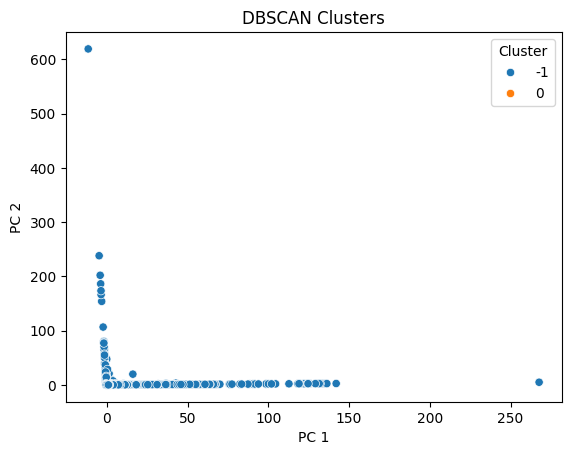

In [13]:
# project data onto first two principal components
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df[NumericCols])  # omit cluster, categorical, and locations
df['PC1'] = pca_components[:, 0]
df['PC2'] = pca_components[:, 1]

# 2D view in PCA space
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='tab10', data=df, legend='full')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('DBSCAN Clusters')   
plt.show()

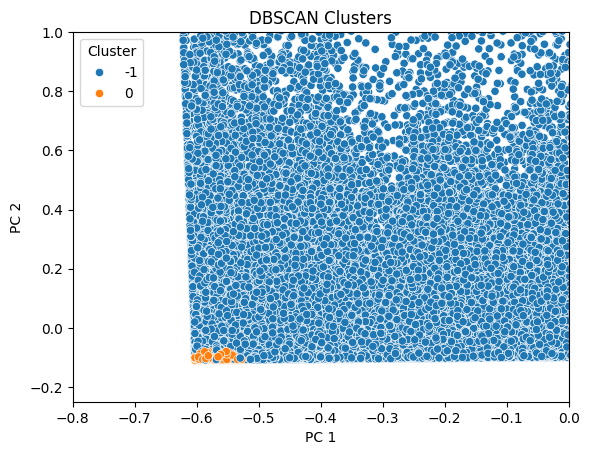

In [14]:
# zoom in
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='tab10', data=df, legend='full')
plt.title('DBSCAN Clusters')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.xlim([-0.8, 0])  
plt.ylim([-0.25, 1])   
plt.show()

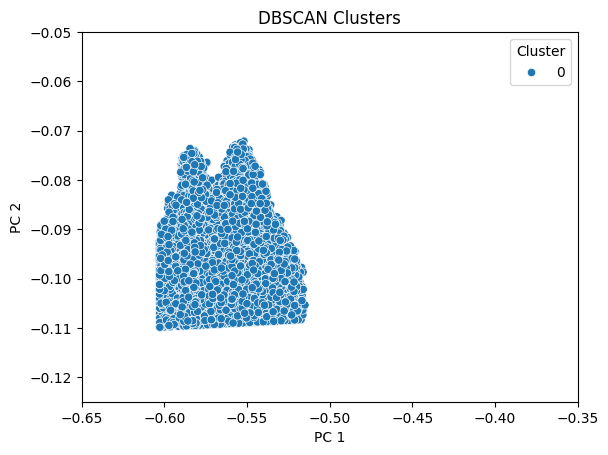

In [15]:
# zooming further and omitting the noise shows PC 1 is a decent descriminator for the non-noise clusters
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='tab10', data=df[df['Cluster'] != -1], legend='full')
plt.title('DBSCAN Clusters')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.xlim([-0.65, -0.35])  
plt.ylim([-0.125, -0.05])   
plt.show()


In [16]:
# check centroids for cluster interpretation clues
cluster_centroids = OriginalData[NumericCols + ['Cluster']].groupby('Cluster').mean()
print(cluster_centroids)

         Tot_Benes   Tot_Srvcs  Tot_Bene_Day_Srvcs  Avg_Sbmtd_Chrg  \
Cluster                                                              
-1       87.664434  290.294039          139.000711      425.179593   
 0       19.957531   26.038124           22.335738       27.979967   

         Avg_Mdcr_Alowd_Amt  Avg_Mdcr_Pymt_Amt  Avg_Mdcr_Stdzd_Amt  
Cluster                                                             
-1               111.911497          87.329707           86.364798  
 0                 7.354899           5.902035            5.910273  


In [17]:
# Model 1: IsolationForest

In [18]:
# aim for the same amount of anomalies for all models
contam = 0.005 

# train the IsolationForest model
IFmodel = IsolationForest(n_estimators=500, 
                        contamination=contam, 
                        random_state=1656)
IFmodel.fit(df[ModelCols].values) # complains about header, so gave it a headerless np array 

,n_estimators,500
,max_samples,'auto'
,contamination,0.005
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,1656
,verbose,0
,warm_start,False


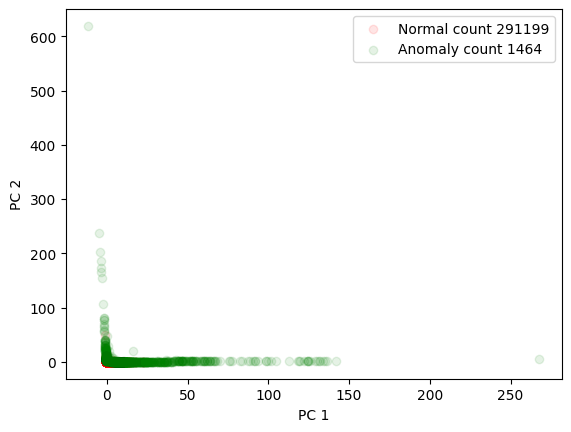

In [19]:
# get the labels (1 for normal, -1 for anomalies)
IFscores = IFmodel.predict(df[ModelCols].values)

# get PCA 1 and 2 for both classes
pc1_normal = df['PC1'][IFscores == 1]
pc2_normal = df['PC2'][IFscores == 1]
pc1_anom = df['PC1'][IFscores == -1]
pc2_anom = df['PC2'][IFscores == -1]

# overlay the anomalies on the normal data
plt.scatter(pc1_normal, pc2_normal, alpha=0.1, color='red',label=f'Normal count {len(pc1_normal)}')
plt.scatter(pc1_anom, pc2_anom, alpha=0.1, color='green',label=f'Anomaly count {len(pc1_anom)}')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.show()

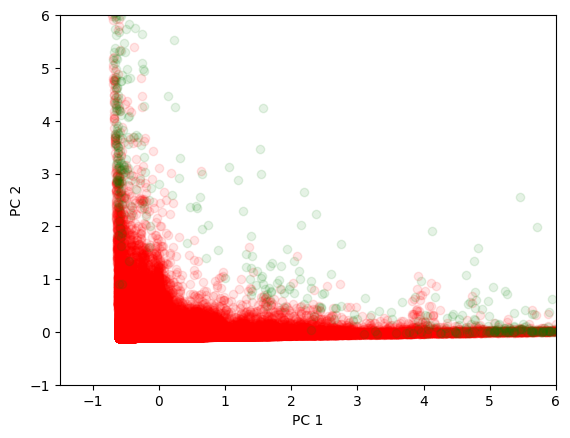

In [20]:
# zoom in
plt.scatter(pc1_normal, pc2_normal, alpha=0.1, color='red',label=f'Normal count {len(pc1_normal)}')
plt.scatter(pc1_anom, pc2_anom, alpha=0.1, color='green',label=f'Anomaly count {len(pc1_anom)}')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.xlim([-1.5, 6])  
plt.ylim([-1, 6])   
plt.show()

In [21]:
# Model 2: AutoEncoder

In [22]:
df[ModelCols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292663 entries, 0 to 292662
Data columns (total 19 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Tot_Benes                        292663 non-null  float64
 1   Tot_Srvcs                        292663 non-null  float64
 2   Tot_Bene_Day_Srvcs               292663 non-null  float64
 3   Avg_Sbmtd_Chrg                   292663 non-null  float64
 4   Avg_Mdcr_Alowd_Amt               292663 non-null  float64
 5   Avg_Mdcr_Pymt_Amt                292663 non-null  float64
 6   Avg_Mdcr_Stdzd_Amt               292663 non-null  float64
 7   latitude                         292663 non-null  float64
 8   longitude                        292663 non-null  float64
 9   credential_DO                    292663 non-null  bool   
 10  credential_MD                    292663 non-null  bool   
 11  credential_NONE                  292663 non-null  bool   
 12  cr

In [23]:
# train the AutoEncoder model
AEmodel = AutoEncoder(hidden_neuron_list =[12, 8, 4, 2], 
                      epoch_num = 10, 
                      contamination = contam) 
AEmodel.fit(df[ModelCols])

Training: 100%|█████████████████████████████████| 10/10 [06:47<00:00, 40.79s/it]


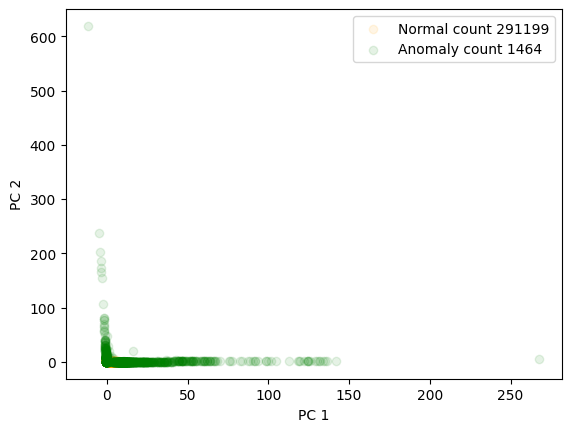

In [24]:
# get PC 1 and 2 for AE anomalies
AEscores = AEmodel.decision_scores_
AEpc1_normal = df['PC1'][AEscores <= AEmodel.threshold_]
AEpc2_normal = df['PC2'][AEscores <= AEmodel.threshold_]
AEpc1_anom = df['PC1'][AEscores > AEmodel.threshold_]
AEpc2_anom = df['PC2'][AEscores > AEmodel.threshold_]

# overlay the anamolies on the normal data
plt.scatter(AEpc1_normal, AEpc2_normal, alpha=0.1, color='orange',label=f'Normal count {len(AEpc1_normal)}')
plt.scatter(AEpc1_anom, AEpc2_anom, alpha=0.1, color='green',label=f'Anomaly count {len(AEpc1_anom)}')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.show()

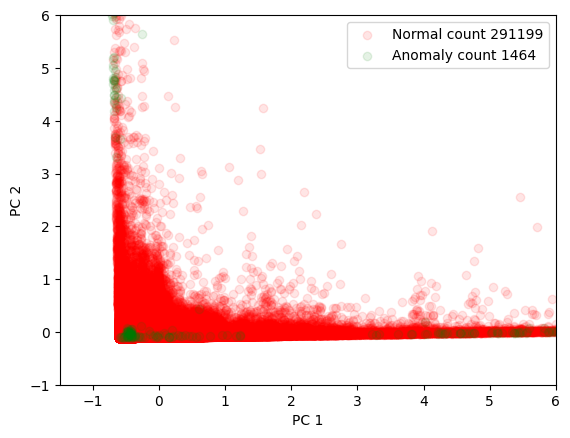

In [25]:
plt.scatter(AEpc1_normal, AEpc2_normal, alpha=0.1, color='red',label=f'Normal count {len(AEpc1_normal)}')
plt.scatter(AEpc1_anom, AEpc2_anom, alpha=0.1, color='green',label=f'Anomaly count {len(AEpc1_anom)}')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.xlim([-1.5, 6])  
plt.ylim([-1, 6]) 
plt.legend()
plt.show()

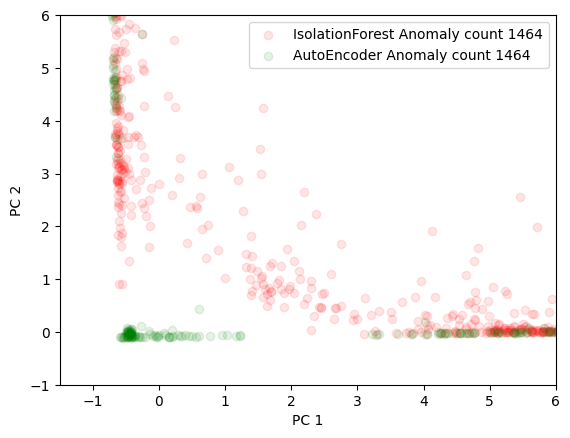

In [26]:
plt.scatter(pc1_anom, pc2_anom, alpha=0.1, color='red',label=f'IsolationForest Anomaly count {len(pc1_anom)}')
plt.scatter(AEpc1_anom, AEpc2_anom, alpha=0.1, color='green',label=f'AutoEncoder Anomaly count {len(AEpc1_anom)}')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.xlim([-1.5, 6])  
plt.ylim([-1, 6]) 
plt.legend()
plt.show()

In [27]:
# Find anomalies that both models agree on

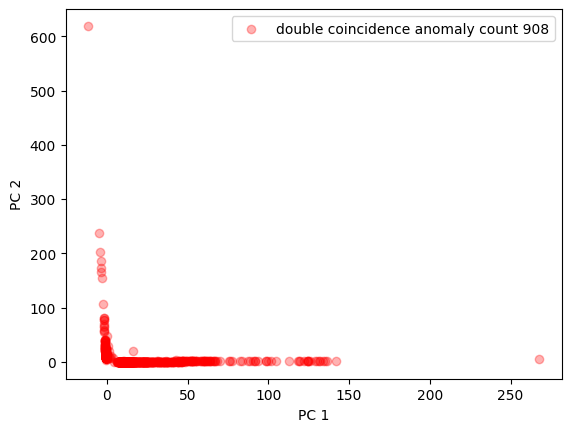

In [28]:
AEAnomalyIndex = AEscores >= AEmodel.threshold_
IFAnomalyIndex = IFscores == -1
DoubleAnomalyIndex = AEAnomalyIndex & IFAnomalyIndex
DoublePC1 = df['PC1'][DoubleAnomalyIndex]
DoublePC2 = df['PC2'][DoubleAnomalyIndex]
plt.scatter(DoublePC1, DoublePC2, alpha=0.3, color='red',label=f'double coincidence anomaly count {sum(DoubleAnomalyIndex)}')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.show()

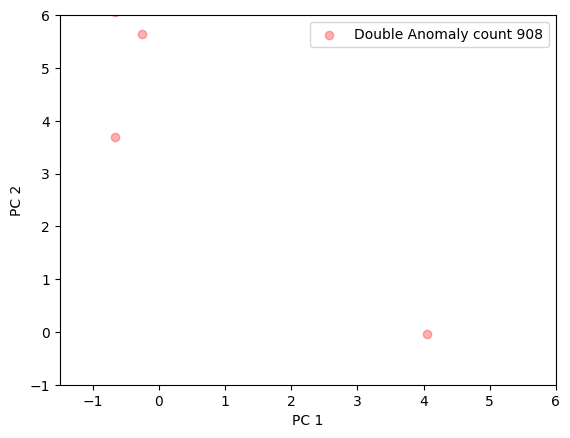

In [29]:
# zooming in shows we exclude most everything near the PC origin
plt.scatter(DoublePC1, DoublePC2, alpha=0.3, color='red',label=f'Double Anomaly count {sum(DoubleAnomalyIndex)}')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.xlim([-1.5, 6])  
plt.ylim([-1, 6]) 
plt.legend()
plt.show()

In [30]:
# check overall data reduction factor
ReductionFactor = len(DoublePC1) / len(df)
print(f"Data reduction factor: {np.round(ReductionFactor,4)}")

Data reduction factor: 0.0031


In [31]:
# Explore the Anomalies

In [32]:
# extract the anomalies
Anomalies = OriginalData[DoubleAnomalyIndex]

# gender indicator
Anomalies['Rndrng_Prvdr_Gndr'].value_counts(normalize=True)

Rndrng_Prvdr_Gndr
none    0.610132
M       0.351322
F       0.038546
Name: proportion, dtype: float64

In [33]:
OriginalData['Rndrng_Prvdr_Gndr'].value_counts(normalize=True)


Rndrng_Prvdr_Gndr
M       0.604135
F       0.340535
none    0.055330
Name: proportion, dtype: float64

In [34]:
# medicare iarticipation indicator
Anomalies['Rndrng_Prvdr_Mdcr_Prtcptg_Ind'].value_counts()

Rndrng_Prvdr_Mdcr_Prtcptg_Ind
Y    908
Name: count, dtype: int64

In [35]:
# credential indicator
OriginalData['credential'].value_counts(normalize=True)

credential
MD       0.585253
other    0.213047
NONE     0.106310
DO       0.065714
PA-C     0.029676
Name: proportion, dtype: float64

In [36]:
Anomalies['credential'].value_counts(normalize=True)


credential
NONE     0.621145
MD       0.295154
DO       0.044053
other    0.039648
Name: proportion, dtype: float64

In [37]:
# anomalies are all are from the noise cluster, so trying triple coincidence 
# with DBSCAN's noise cluster as the third anomaly label wouldn't reduce our anomaly set further
Anomalies['Cluster'].value_counts(normalize=True)

Cluster
-1    1.0
Name: proportion, dtype: float64

In [38]:
# quick look at the numeric features
Anomalies[NumericCols].describe()

,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
count,908.000000,9.080000e+02,908.000000,908.000000,908.000000,908.000000,908.000000
mean,4036.825991,1.549971e+04,6090.901982,13273.437580,3307.832934,2644.963300,2654.673093
std,20678.648312,1.532909e+05,26967.595793,15497.396805,4498.892151,3589.326675,3669.322476
min,11.000000,1.100000e+01,11.000000,0.010000,0.010000,0.010000,0.010000
25%,15.000000,1.600000e+01,16.000000,4552.500000,1279.623620,1013.187787,1022.328339
50%,25.000000,2.850000e+01,28.000000,8873.350000,1874.761079,1507.926295,1498.173725
75%,72.500000,9.125000e+01,83.000000,16003.750000,3780.092328,3049.586931,3058.384737
max,455358.000000,3.643111e+06,455392.000000,99999.990000,52799.051765,42147.706471,41679.064118


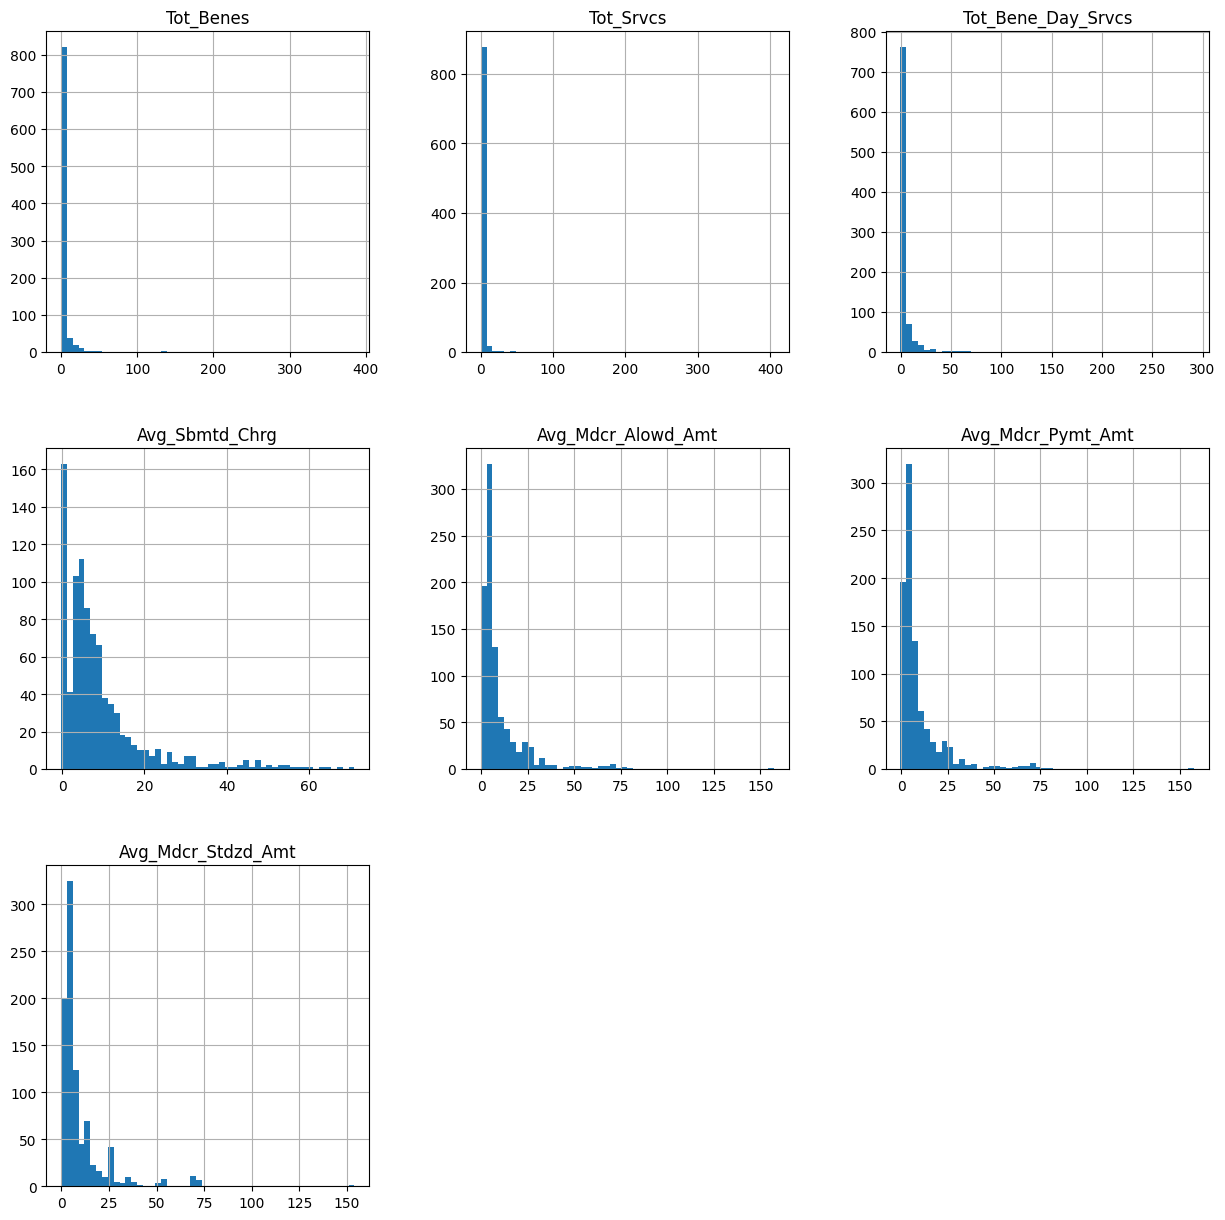

In [39]:
# get z-scores for all numeric features from main data
z_scores = df[NumericCols].apply(zscore)

# extract those of the anomalies
anomalies_z_scores = z_scores[DoubleAnomalyIndex] 

# make histograms for anomaly z-scores for each numeric feature
anomalies_z_scores.hist(bins=50,figsize=(15,15));

In [40]:
# none of the anomalies have the dummy location
num_dummy_entries = Anomalies[(Anomalies['latitude'] == dummy_lat) & (Anomalies['longitude'] == dummy_lng)].shape[0]
print(f"Number of entries assigned the dummy location: {num_dummy_entries}")

Number of entries assigned the dummy location: 0


In [41]:
# train a decision tree that finds these anomalies in the full data
# to see what features proved most imporant in finding them
tree_clf = DecisionTreeClassifier()
tree_clf.fit(df[ModelCols], DoubleAnomalyIndex)
feature_importances = pd.Series(tree_clf.feature_importances_, index=ModelCols)
print(feature_importances.sort_values(ascending=False))


Avg_Mdcr_Pymt_Amt                  0.581621
Tot_Bene_Day_Srvcs                 0.155196
Avg_Sbmtd_Chrg                     0.096805
credential_MD                      0.057235
Avg_Mdcr_Stdzd_Amt                 0.045421
Rndrng_Prvdr_Gndr_none             0.011467
Avg_Mdcr_Alowd_Amt                 0.011182
Tot_Benes                          0.010980
longitude                          0.009364
Tot_Srvcs                          0.008579
latitude                           0.006375
credential_DO                      0.004184
Rndrng_Prvdr_Gndr_F                0.000967
Rndrng_Prvdr_Gndr_M                0.000496
credential_other                   0.000128
credential_NONE                    0.000000
credential_PA-C                    0.000000
Rndrng_Prvdr_Mdcr_Prtcptg_Ind_N    0.000000
Rndrng_Prvdr_Mdcr_Prtcptg_Ind_Y    0.000000
dtype: float64
